# **MACHINE LEARNING**
## **EDA — Prediciendo la Diabetes**



In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import joblib
import os

In [42]:
# Carga del dataset

csv_file_path = "/content/sample_data/diabetes.csv"
df = pd.read_csv(csv_file_path)

print(df.shape)
df.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Este dataset tiene **768 filas y 9 columnas**, todas las variables son numéricas.


In [43]:
# 2.1 INFORMACIÓN GENERAL DEL DATASET

print(" INFORMACIÓN GENERAL DEL DATASET")
df.info()

 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Vemos que el dataset **no tiene ningun valor nulo.** y que todas las columnas tienen valores de tipo numérico, tanto `int` como `float`.

In [44]:
# 2.2 ESTADÍSTICAS DESCRIPTIVAS

df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


`.describe()` nos muestra las estadísticas descriptivas de todas las columnas, vemos que hay varias columnas con mínimos de cero, algo que es imposible, no se puede tener `Glucose`, `BloodPressure`, `SkinThickness` por ejemplo, con valores cero. Esto nos indica **valores faltantes.**

In [45]:
# 2.3 VALORES NULOS

print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n Total valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Total valores nulos: 0


Podemos observar que no tenemos **nungun valor nulo** en ninguna columna del dataset.

In [46]:
# 2.4 VALORES CERO (POTENCIALMENTE VALORES FALTANTES)

# En este dataset, ciertas columnas no deberían tener ceros fisiológicamente:
# Glucose, BloodPressure, SkinThickness, Insulin, BMI
cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Valores cero en columnas médicas (probables valores faltantes):")
for col in cols_con_ceros:
    ceros = (df[col] == 0).sum()
    pct = ceros / len(df) * 100
    print(f"   {col:30s} → {ceros:3d} ceros ({pct:.1f}%)")

Valores cero en columnas médicas (probables valores faltantes):
   Glucose                        →   5 ceros (0.7%)
   BloodPressure                  →  35 ceros (4.6%)
   SkinThickness                  → 227 ceros (29.6%)
   Insulin                        → 374 ceros (48.7%)
   BMI                            →  11 ceros (1.4%)


Vemos muchos ceros en las columnas `SkinThickness` y `Insuline` en ninguna de estas 5 columnas debería haber valor cero, ya que es biologicamente imposible.


In [47]:
# 2.5 TRATAMIENTO DE VALORES CERO → IMPUTACIÓN POR MEDIANA

df_clean = df.copy()

for col in cols_con_ceros:
    mediana = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, mediana)
    print(f" {col}: 0s → mediana = {mediana:.2f}")

print("\nImputación completada")

 Glucose: 0s → mediana = 117.00
 BloodPressure: 0s → mediana = 72.00
 SkinThickness: 0s → mediana = 29.00
 Insulin: 0s → mediana = 125.00
 BMI: 0s → mediana = 32.30

Imputación completada


He cambiado las los valores **cero** de las columanas por su correspondiente mediana. Es importante reemplazar los valores cero, ya que nadie vivo puede tener la presion arterial = 0.

He usado la mediana en vez de la media porque resiste mejor los outliers, por ejemplo en `Insulin` vemos fuertes outliers, esto disparar'ia la media.

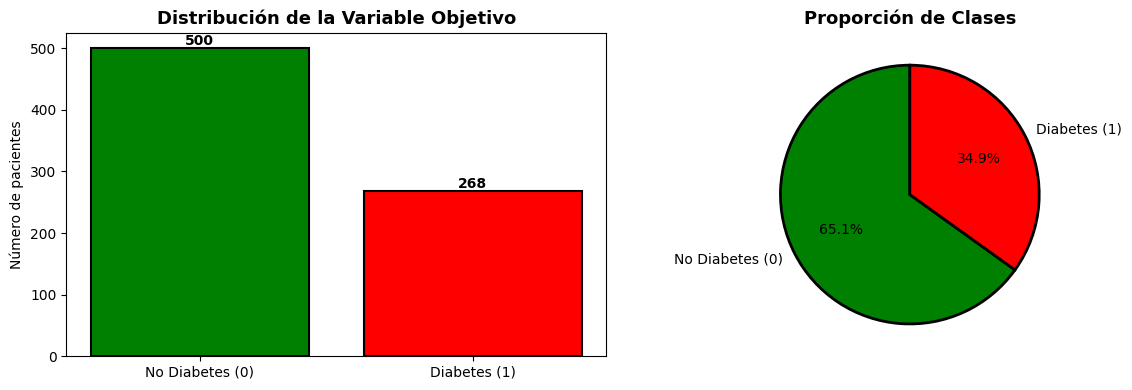


 Distribución:
   No Diabetes (0): 500 pacientes (65.1%)
   Diabetes    (1): 268 pacientes (34.9%)

 Hay cierto desbalance de clases (más negativos que positivos)


In [48]:
# 2.6 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
counts = df_clean['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
            counts.values,
            color=['green', 'red'],
            edgecolor='black',
            linewidth=1.5)
axes[0].set_title('Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(counts.values,
            labels=['No Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%',
            colors=['green', 'red'],
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Distribución:")
print(f"   No Diabetes (0): {counts[0]} pacientes ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"   Diabetes    (1): {counts[1]} pacientes ({counts[1]/len(df_clean)*100:.1f}%)")
print("\n Hay cierto desbalance de clases (más negativos que positivos)")

Podemos observar un desbalance de clases, hay un **65% de No Diabetes** vs un **35% de Diabetes.** Es importnate mantener esta proporción en el modelo.

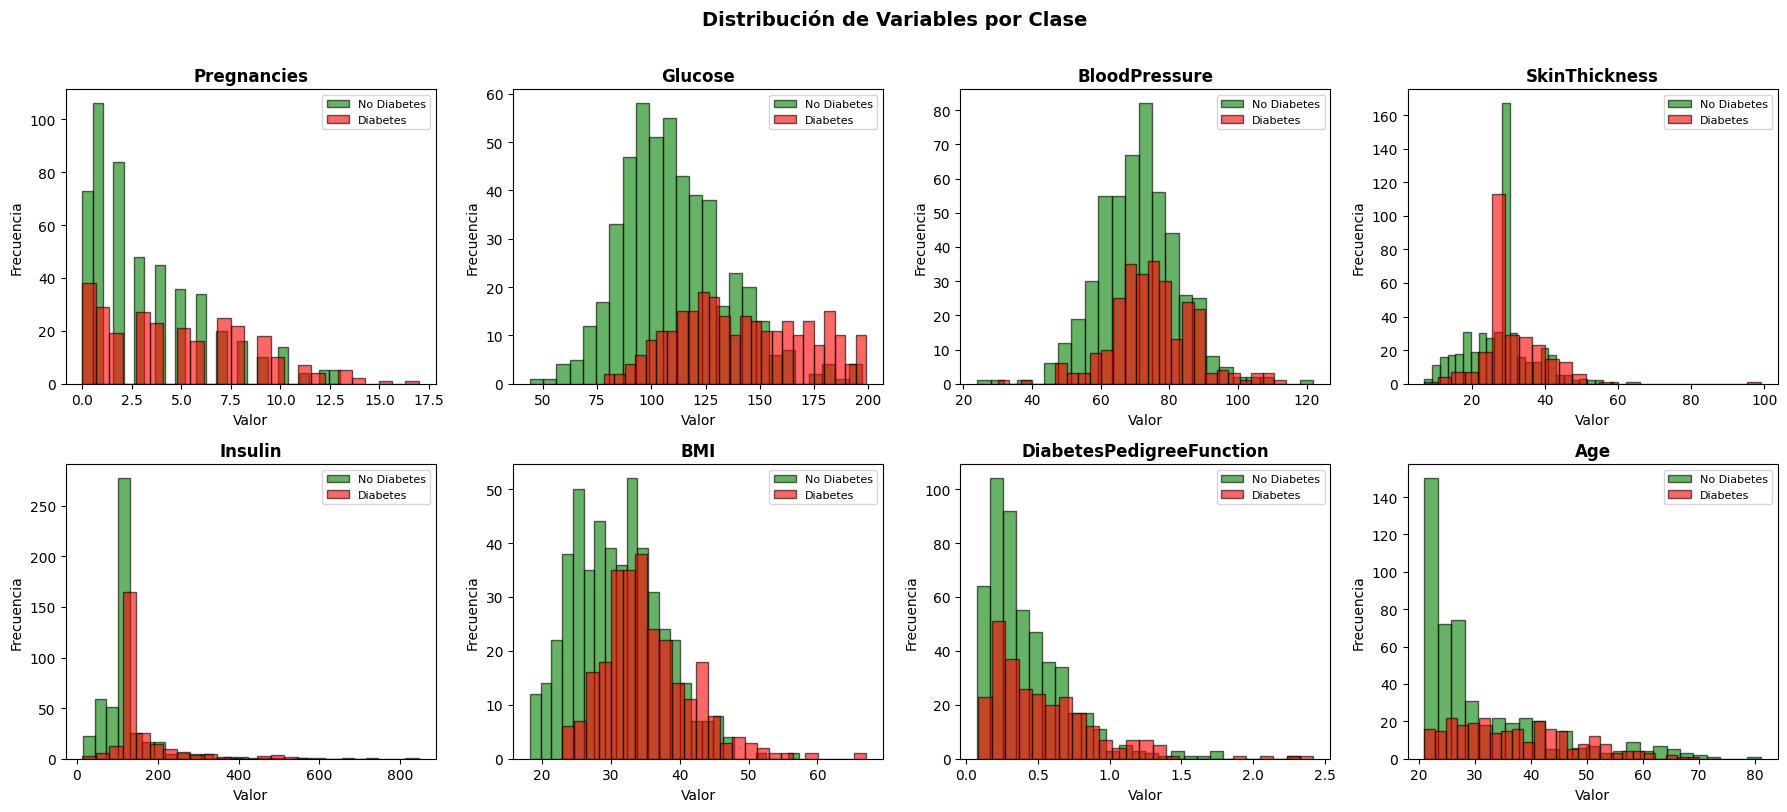

In [49]:
# 2.7 DISTRIBUCIÓN DE CADA VARIABLE

features = [c for c in df_clean.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[df_clean['Outcome'] == 0][col],
                 bins=25,
                 alpha=0.6,
                 color='green',
                 label='No Diabetes',
                 edgecolor='black')
    axes[i].hist(df_clean[df_clean['Outcome'] == 1][col],
                 bins=25,
                 alpha=0.6,
                 color='red',
                 label='Diabetes',
                 edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables por Clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos histogramas superpuestos nos revelan que variables diferencian mejor diabeticos de no diabeticos:
- **Glucose**: obviamente la glucosa es el valor que más diferencia a dibeticos de no dibeticos.
- **BMI** y **Age**: También nos muestra claras diferencias.
- **SkinThickness** e **Insulin**: Muestran diferencias más leves.

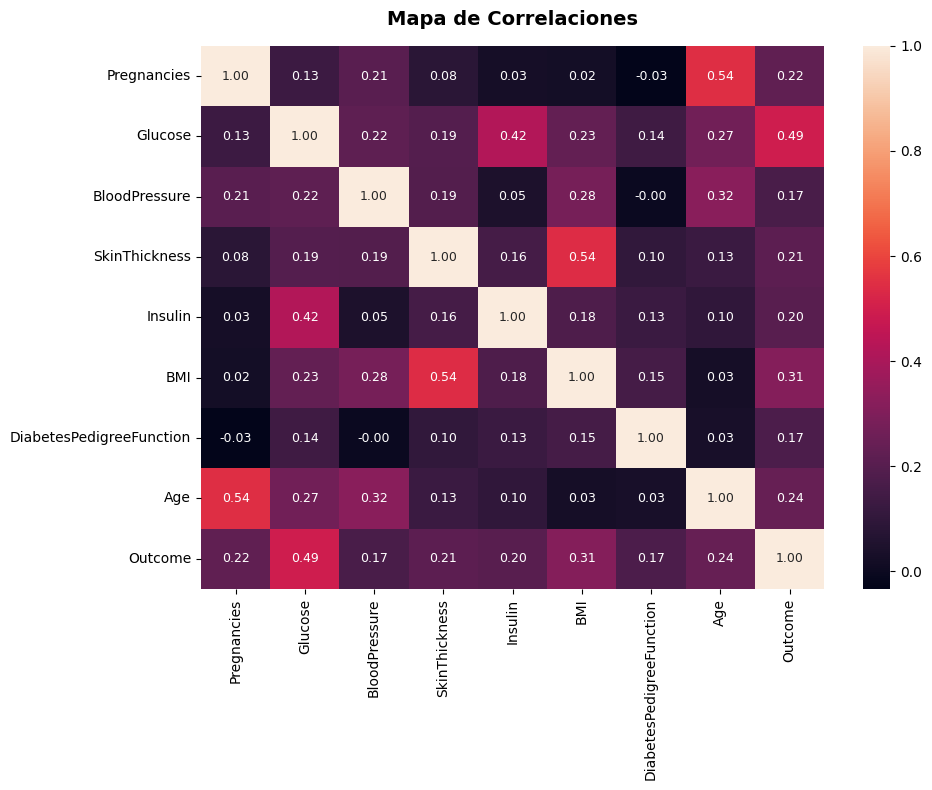

In [50]:
# 2.8 MAPA DE CORRELACIONES

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            ax=ax,
            annot_kws={'size': 9})
ax.set_title('Mapa de Correlaciones', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()




Este heatmap nos confirma que la variable más correlacionada con `Outcome` es `Glucose` con casi un 0.50. Seguidas de `BMI`, `Age` y `Pregnancies`.

Las correlaciones en general son bajas, esto beneficia al decission tree.

/tmp/ipykernel_12211/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_12211/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_12211/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_12211/1541366649.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],


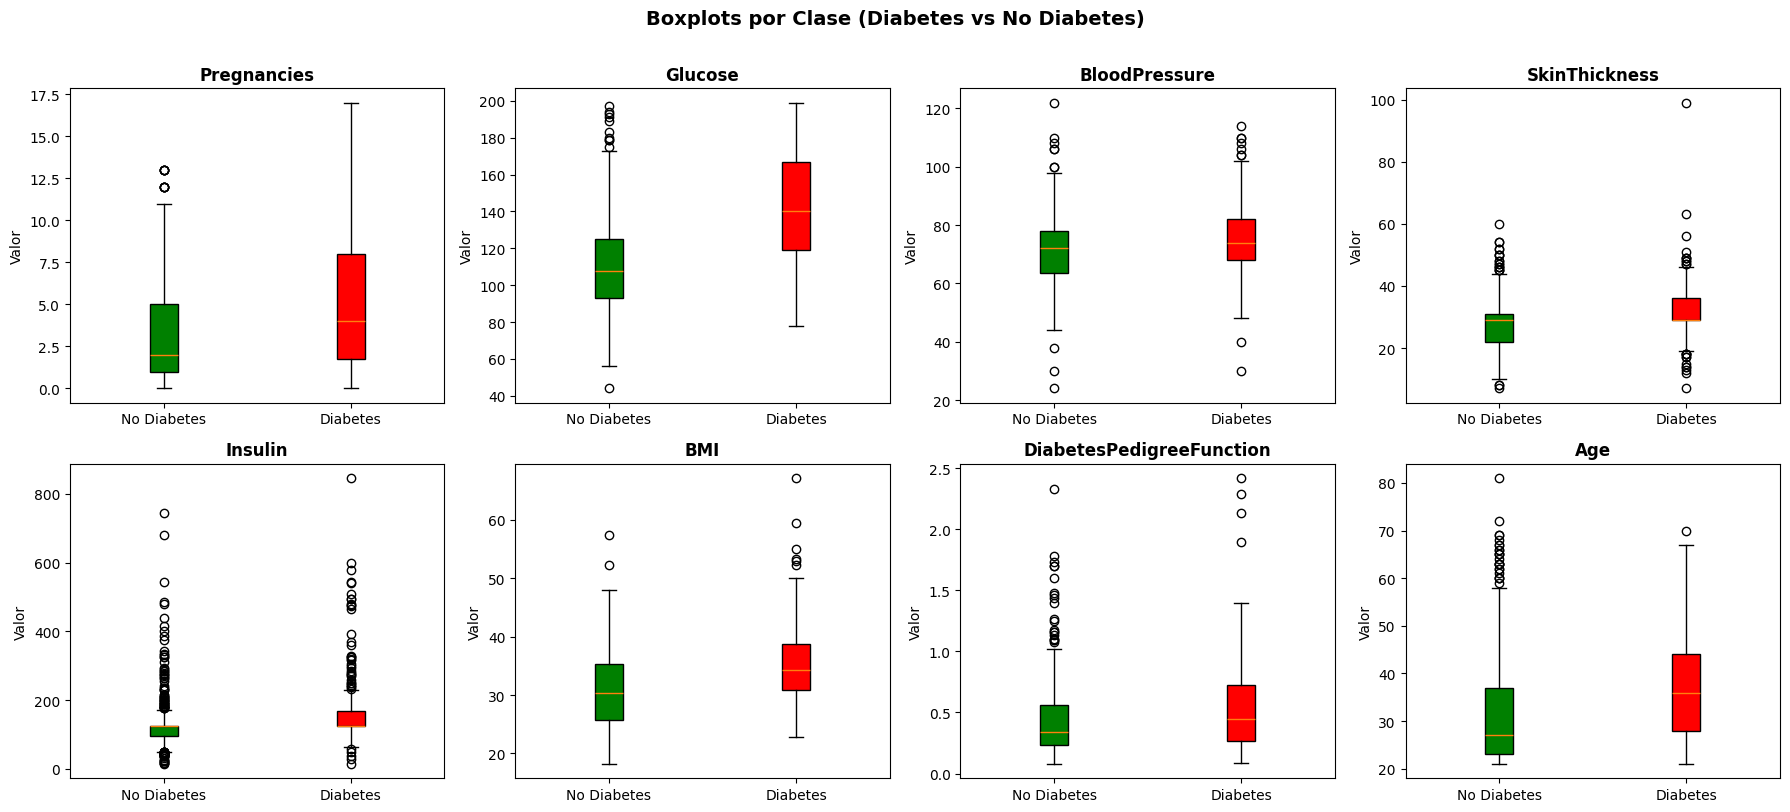

In [51]:
# 2.9 BOXPLOTS POR CLASE

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    data_no = df_clean[df_clean['Outcome'] == 0][col]
    data_si = df_clean[df_clean['Outcome'] == 1][col]
    bp = axes[i].boxplot([data_no, data_si],
                          patch_artist=True,
                          labels=['No Diabetes', 'Diabetes'])
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots por Clase (Diabetes vs No Diabetes)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos boxplots muestran **medianas, cuartiles y outliers** de cada variable, vamos a ver algunos.
- **Glucose**: la median de diabeticos esta por encima de la de no diabetcos.
- **Insulin** y **SkinThickness**: podemos apreciar muchos outliers.
- Aunque hay diferencias, vemos que no hay demasiada en **BloodPreasure**.

Top 5 variables más correlacionadas con Outcome: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']


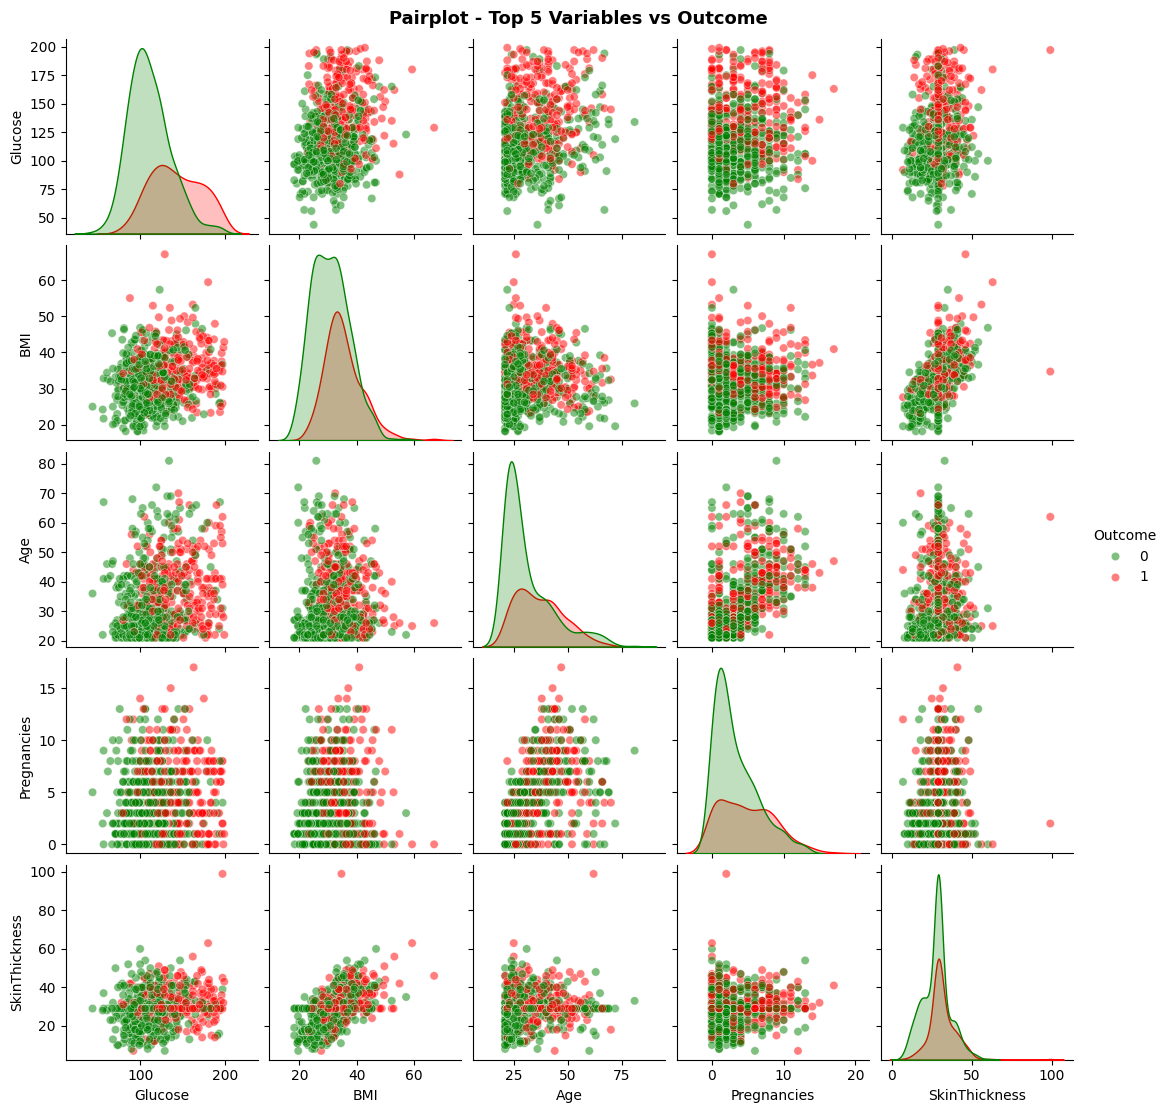

In [52]:
# 2.10 PAIRPLOT DE VARIABLES MÁS RELEVANTES

corr_target = df_clean.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
top_features = corr_target.head(5).index.tolist() + ['Outcome']
print(f"Top 5 variables más correlacionadas con Outcome: {top_features[:-1]}")

sns.pairplot(df_clean[top_features],
             hue='Outcome',
             palette={0: 'green', 1: 'red'},
             height=2.2,
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot - Top 5 Variables vs Outcome', y=1.01, fontsize=13, fontweight='bold')
plt.show()

El pairplot es un gráfico que cruza cada variable con `Outcome`, podemos apreciar que el par `Glucose + BMI` muestra la mayor separación visual.


In [53]:
# 2.11 DETECCIÓN DE OUTLIERS (IQR)

print("Detección de outliers por columna (método IQR):")
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / len(df_clean) * 100
    print(f"  {col:30s}: {outliers:3d} outliers ({pct:.1f}%)")

print("\n Nota: Los outliers se mantienen ya que en datos médicos pueden ser clínicamente relevantes.")

Detección de outliers por columna (método IQR):
  Pregnancies                   :   4 outliers (0.5%)
  Glucose                       :   0 outliers (0.0%)
  BloodPressure                 :  14 outliers (1.8%)
  SkinThickness                 :  87 outliers (11.3%)
  Insulin                       : 346 outliers (45.1%)
  BMI                           :   8 outliers (1.0%)
  DiabetesPedigreeFunction      :  29 outliers (3.8%)
  Age                           :   9 outliers (1.2%)

 Nota: Los outliers se mantienen ya que en datos médicos pueden ser clínicamente relevantes.


Se puede apreciar que `Insulin` es la variable con mayor porcenatje de outliers, seguido de `SkinThickness` y `DiabetesPedigreeFunction`, los árboles de decisión trabajan bien los outliers y no se ven aectados por valores extremos.


##CONCLUSIONES DEL EDA
1. El dataset tiene 768 muestras y 9 variables, sin valores nulos.
2. He detectado valores cero en columnas médicas (Glucose, BloodPressure,
   SkinThickness, Insulin, BMI) cambiados por la mediana.
3. Hay desbalance de clases: 65% No Diabetes / 35% Diabetes.
4. Las variables con mayor correlación con Outcome son:
   1. Glucose (la más importante)
   2. BMI
   3. Age
   4. Pregnancies
   5. DiabetesPedigreeFunction
5. No hay variables con correlación alta entre sí, no hay
   multicolinealidad grave.


---
# **PASO 3: Construcción del Random Forest**

Un **Random Forest** es un ensamble de árboles de decisión entrenados sobre subconjuntos aleatorios de datos y features. La predicción final se obtiene por votación mayoritaria entre todos los árboles, lo que reduce el overfitting y mejora la generalización.

### Hiperparámetros clave analizados:
| Parámetro | Descripción |
|---|---|
| `n_estimators` | Número de árboles del bosque. Más árboles = más estabilidad, pero más coste computacional |
| `max_depth` | Profundidad máxima de cada árbol. Controla la complejidad y el overfitting |

In [54]:
# 3.0 SPLIT TRAIN / TEST

# Separo las features (X) de la variable objetivo (y)
X = df_clean.drop('Outcome', axis=1)   # Todas las columnas menos la que voy predecir
y = df_clean['Outcome']                 # Variable objetivo: 0 = No Diabetes, 1 = Diabetes

# Dividimos en 80% entrenamiento y 20% test
# random_state=42 garantiza reproducibilidad (misma división siempre)
# stratify=y asegura que la proporción de clases (65%/35%) se conserve en ambos splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantiene la proporción de clases en ambos splits
)

print(f" División del dataset (stratified split):")
print(f"   Train → {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  → {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Proporción Outcome en Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   Proporción Outcome en Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

 División del dataset (stratified split):
   Train → 614 muestras (80%)
   Test  → 154 muestras  (20%)

   Proporción Outcome en Train: {0: 0.651, 1: 0.349}
   Proporción Outcome en Test:  {0: 0.649, 1: 0.351}


In [55]:
# 3.1 ENTRENAMIENTO DEL RANDOM FOREST BASE
# Entrenamos un primer modelo con unos parámetros por defecto como línea de referencia
# n_estimators=100 es el valor por defecto de scikit-learn

# class_weight='balanced' compensa el desbalance de clases (65%/35%)
# ajustando internamente la importancia de cada clase según su frecuencia
rf_base = RandomForestClassifier(
    n_estimators=100,       # 100 árboles en el bosque
    random_state=42,        # Reproducibilidad
    class_weight='balanced' # Corrige desbalance: penaliza más los errores en la clase minoritaria
)
rf_base.fit(X_train, y_train)   # Entrenamos sobre los datos de entrenamiento

# Predicciones sobre train y test
y_pred_base = rf_base.predict(X_test)
y_pred_train_base = rf_base.predict(X_train)

# Métricas del modelo base
acc_test_base  = accuracy_score(y_test, y_pred_base)
acc_train_base = accuracy_score(y_train, y_pred_train_base)
cv_base = cross_val_score(rf_base, X, y, cv=5, scoring='accuracy')

print(f" Modelo Random Forest Base (n_estimators=100, max_depth=None):")
print(f"   Accuracy Train:  {acc_train_base:.4f}")
print(f"   Accuracy Test:   {acc_test_base:.4f}")
print(f"   CV Accuracy:     {cv_base.mean():.4f} ± {cv_base.std():.4f}")
print(f"   Overfitting:     {acc_train_base - acc_test_base:.4f}")

 Modelo Random Forest Base (n_estimators=100, max_depth=None):
   Accuracy Train:  1.0000
   Accuracy Test:   0.7468
   CV Accuracy:     0.7540 ± 0.0309
   Overfitting:     0.2532


In [56]:
# 3.2 IMPACTO DE n_estimators
# Analizo cómo va cambiando el accuracy tras el número de árboles del bosque
# Pocos árboles hace el modelo inestable; con muchos mejora pero cdecrece el rendimiento.

n_estimators_values = [5, 10, 25, 50, 100, 200, 300, 500]
results_n = {}

for n in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, rf.predict(X_train))
    acc_test  = accuracy_score(y_test, rf.predict(X_test))

    results_n[n] = {'train': acc_train, 'test': acc_test}
    print(f"   n_estimators={n:4d}  →  Train: {acc_train:.4f}  |  Test: {acc_test:.4f}")

   n_estimators=   5  →  Train: 0.9837  |  Test: 0.7208
   n_estimators=  10  →  Train: 0.9821  |  Test: 0.7208
   n_estimators=  25  →  Train: 1.0000  |  Test: 0.7468
   n_estimators=  50  →  Train: 1.0000  |  Test: 0.7532
   n_estimators= 100  →  Train: 1.0000  |  Test: 0.7468
   n_estimators= 200  →  Train: 1.0000  |  Test: 0.7403
   n_estimators= 300  →  Train: 1.0000  |  Test: 0.7468
   n_estimators= 500  →  Train: 1.0000  |  Test: 0.7468


In [57]:
# 3.3 IMPACTO DE max_depth
# Analizo cómo cambia el accuracy al limitar la profundidad de cada árbol
# max_depth=None significa que los árboles crecen sin límite (más riesgo de overfitting)

max_depth_values = [1, 2, 3, 5, 7, 10, 15, 20, None]
results_d = {}

for d in max_depth_values:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d,
                                 random_state=42, class_weight='balanced')
    rf.fit(X_train, y_train)

    acc_train = accuracy_score(y_train, rf.predict(X_train))
    acc_test  = accuracy_score(y_test, rf.predict(X_test))

    results_d[d] = {'train': acc_train, 'test': acc_test}
    label = str(d) if d is not None else 'None'
    print(f"   max_depth={label:4s}  →  Train: {acc_train:.4f}  |  Test: {acc_test:.4f}")

   max_depth=1     →  Train: 0.7769  |  Test: 0.7338
   max_depth=2     →  Train: 0.7964  |  Test: 0.7532
   max_depth=3     →  Train: 0.8160  |  Test: 0.7532
   max_depth=5     →  Train: 0.8502  |  Test: 0.7338
   max_depth=7     →  Train: 0.9104  |  Test: 0.7403
   max_depth=10    →  Train: 0.9870  |  Test: 0.7468
   max_depth=15    →  Train: 1.0000  |  Test: 0.7403
   max_depth=20    →  Train: 1.0000  |  Test: 0.7468
   max_depth=None  →  Train: 1.0000  |  Test: 0.7468


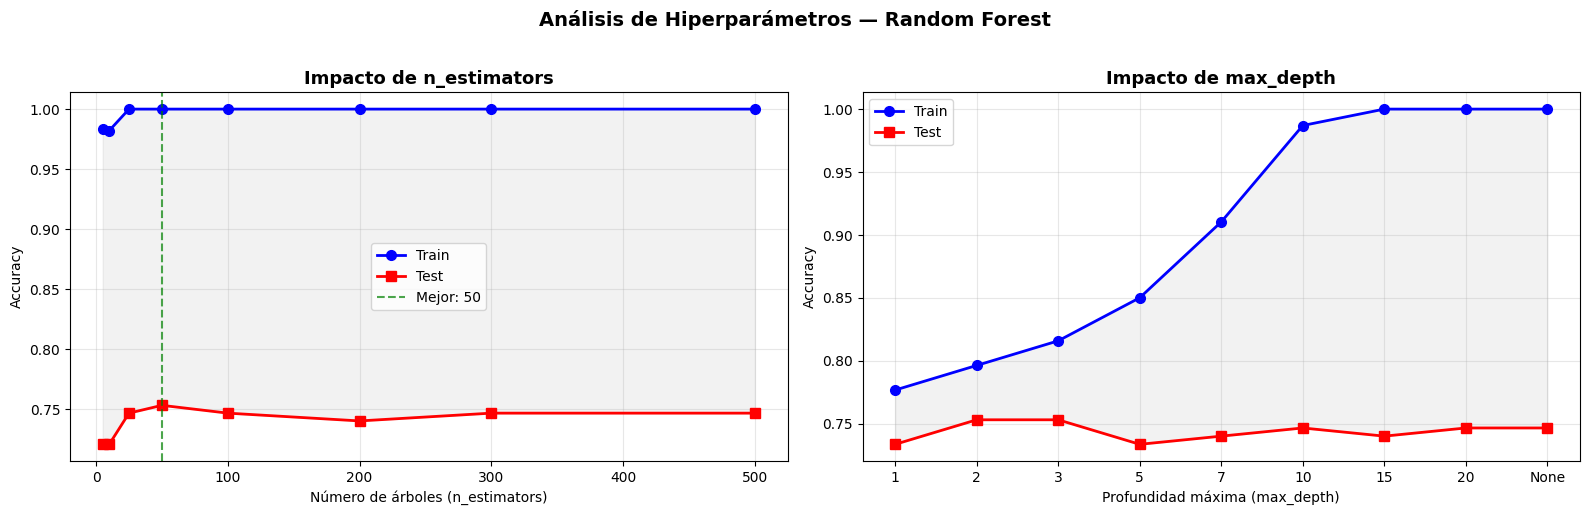


 Mejor n_estimators en test: 50  →  Acc = 0.7532
 Mejor max_depth en test:    2  →  Acc = 0.7532


In [58]:
# 3.4 VISUALIZACIÓN: IMPACTO DE LOS HIPERPARÁMETROS
# Creo un grafico de cómo va cambiando el accuracy al variar n_estimators y max_depth
# La diferencia entre ambas curvas nos da el nivel de overfitting

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Gráfico 1: impacto de n_estimators ---
n_vals  = list(results_n.keys())
train_n = [results_n[n]['train'] for n in n_vals]
test_n  = [results_n[n]['test']  for n in n_vals]

axes[0].plot(n_vals,
             train_n,
             'o-',
             color='blue',
             linewidth=2,
             label='Train',
             markersize=7)
axes[0].plot(n_vals,
             test_n,
             's-',
             color='red',
             linewidth=2,
             label='Test',
             markersize=7)
axes[0].fill_between(n_vals, train_n, test_n, alpha=0.1, color='gray')  # Zona de overfitting
axes[0].set_title('Impacto de n_estimators', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Número de árboles (n_estimators)')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

# Marco el mejor valor en test
best_n = max(results_n, key=lambda n: results_n[n]['test'])
axes[0].axvline(x=best_n,
                color='green',
                linestyle='--',
                alpha=0.7,
                label=f'Mejor: {best_n}')
axes[0].legend()

# --- Gráfico 2: impacto de max_depth ---
# Convierto None a una etiqueta para el eje x
depth_labels = [str(d) if d is not None else 'None' for d in results_d.keys()]
train_d = [results_d[d]['train'] for d in results_d.keys()]
test_d  = [results_d[d]['test']  for d in results_d.keys()]
x_pos = range(len(depth_labels))

axes[1].plot(x_pos,
             train_d,
             'o-',
             color='blue',
             linewidth=2,
             label='Train',
             markersize=7)
axes[1].plot(x_pos,
             test_d,
             's-',
             color='red',
             linewidth=2,
             label='Test',
             markersize=7)
axes[1].fill_between(x_pos, train_d, test_d, alpha=0.1, color='gray')  # Zona de overfitting
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(depth_labels)
axes[1].set_title('Impacto de max_depth', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Profundidad máxima (max_depth)')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Análisis de Hiperparámetros — Random Forest', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Resumen de mejores valores
best_d = max((d for d in results_d if d is not None),
             key=lambda d: results_d[d]['test'])
print(f"\n Mejor n_estimators en test: {best_n}  →  Acc = {results_n[best_n]['test']:.4f}")
print(f" Mejor max_depth en test:    {best_d}  →  Acc = {results_d[best_d]['test']:.4f}")

In [59]:
# 3.5 MODELO OPTIMIZADO CON LOS MEJORES HIPERPARÁMETROS
# Entrenamiento del modelo final combinando mejores valores de n_estimators y max_depth
# hallados en el análisis anterior

rf_opt = RandomForestClassifier(
    n_estimators=best_n,    # Mejor número de árboles encontrado
    max_depth=best_d,       # Mejor profundidad encontrada
    random_state=42,
    class_weight='balanced'
)
rf_opt.fit(X_train, y_train)

y_pred_opt       = rf_opt.predict(X_test)
y_pred_opt_train = rf_opt.predict(X_train)

acc_opt_test  = accuracy_score(y_test, y_pred_opt)
acc_opt_train = accuracy_score(y_train, y_pred_opt_train)
cv_opt = cross_val_score(rf_opt, X, y, cv=5, scoring='accuracy')

# Tabla comparativa base vs optimizado
print(" COMPARATIVA: MODELO BASE vs MODELO OPTIMIZADO")
print(f"{'Métrica':<25} {'Base':>15} {'Optimizado':>15}")
print(f"{'Accuracy Train':<25} {acc_train_base:>15.4f} {acc_opt_train:>15.4f}")
print(f"{'Accuracy Test':<25} {acc_test_base:>15.4f} {acc_opt_test:>15.4f}")
print(f"{'Overfitting (diff)':<25} {acc_train_base-acc_test_base:>15.4f} {acc_opt_train-acc_opt_test:>15.4f}")
print(f"{'CV Accuracy':<25} {cv_base.mean():>15.4f} {cv_opt.mean():>15.4f}")

 COMPARATIVA: MODELO BASE vs MODELO OPTIMIZADO
Métrica                              Base      Optimizado
Accuracy Train                     1.0000          0.7866
Accuracy Test                      0.7468          0.7532
Overfitting (diff)                 0.2532          0.0334
CV Accuracy                        0.7540          0.7370


Classification Report — Modelo Optimizado:
              precision    recall  f1-score   support

 No Diabetes       0.87      0.73      0.79       100
    Diabetes       0.61      0.80      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



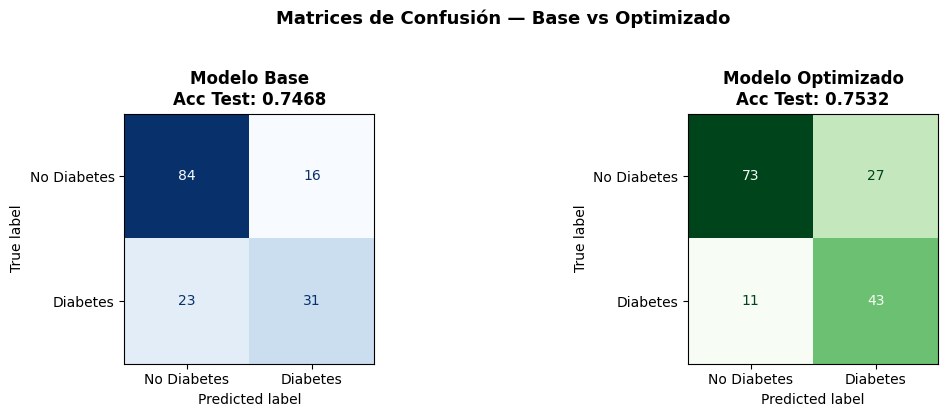

In [60]:
# 3.6 CLASSIFICATION REPORT Y MATRIZ DE CONFUSIÓN
# Evaluación completa del modelo optimizado

print("Classification Report — Modelo Optimizado:")
print(classification_report(y_test, y_pred_opt,
                             target_names=['No Diabetes', 'Diabetes']))

# Matriz de confusión: nos muestra Verdaderos/Falsos Positivos y Negativos
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Modelo base
cm_base = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm_base, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Modelo Base\nAcc Test: {acc_test_base:.4f}', fontweight='bold')

# Modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Modelo Optimizado\nAcc Test: {acc_opt_test:.4f}', fontweight='bold')

plt.suptitle('Matrices de Confusión — Base vs Optimizado', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

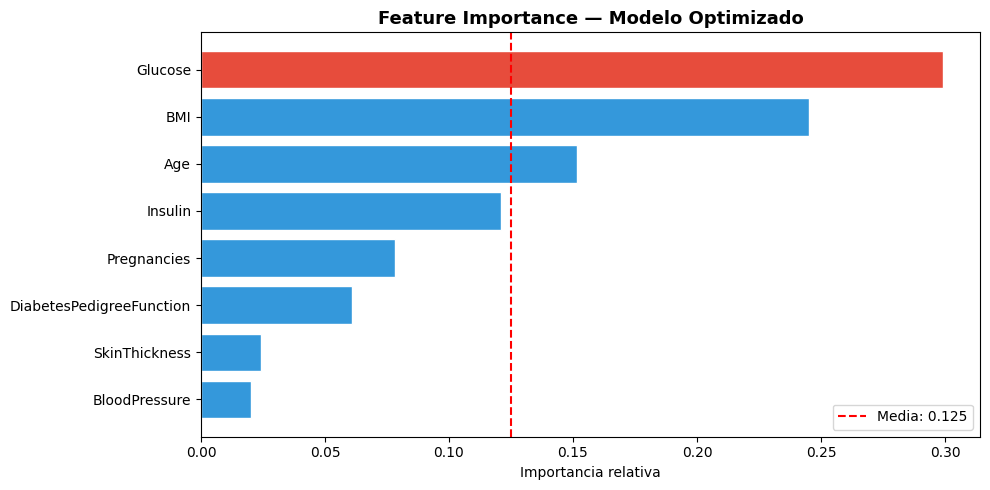

In [61]:
# 3.7 FEATURE IMPORTANCE
# El Random Forest calcula automáticamente la importancia de cada variable
# como la reducción media de impureza (Gini/entropy) ponderada por el número de muestras

importances = rf_opt.feature_importances_             # Importancia de cada feature (suman 1)
indices = np.argsort(importances)[::-1]               # Los ordeno de mayor a menor
feat_names = X.columns[indices]

fig, ax = plt.subplots(figsize=(10, 5))
colors_bar = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(feat_names))]  # Pongo en rojo la más importante
ax.barh(feat_names[::-1], importances[indices][::-1], color=colors_bar[::-1], edgecolor='white')
ax.set_title('Feature Importance — Modelo Optimizado', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.axvline(x=importances.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Media: {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()


In [62]:
# 3.8 ANÁLISIS DE OVERFITTING: TRAIN VS TEST
# Comparación del accuracy en train y test para todos los modelos entrenados
# Hay un modelo que generaliza bien cuando la diferencia Train-Test es pequeña

print(" Análisis de Overfitting:")
print(f"{'Modelo':<30} {'Train Acc':>12} {'Test Acc':>12} {'Diferencia':>12}")

modelos_eval = {
    'Random Forest Base':     (acc_train_base, acc_test_base),
    f'RF Optimizado (n={best_n}, d={best_d})': (acc_opt_train, acc_opt_test),
}

for nombre, (tr, te) in modelos_eval.items():
    diff = tr - te
    flag = 'OVERFITTING' if diff > 0.10 else 'X'
    print(f"{nombre:<30} {tr:>12.4f} {te:>12.4f} {diff:>12.4f}  {flag}")

print(f"""
  Conclusión: El Random Forest reduce el overfitting respecto al árbol individual
   gracias al promediado de múltiples árboles.
   Un valor de overfitting < 0.05 nos indica buena generalización.""")

 Análisis de Overfitting:
Modelo                            Train Acc     Test Acc   Diferencia
Random Forest Base                   1.0000       0.7468       0.2532  OVERFITTING
RF Optimizado (n=50, d=2)            0.7866       0.7532       0.0334  X

  Conclusión: El Random Forest reduce el overfitting respecto al árbol individual
   gracias al promediado de múltiples árboles.
   Un valor de overfitting < 0.05 nos indica buena generalización.


# **PASO 4: Guardado del Modelo**

In [63]:
# 4.1 GUARDAR EL MODELO ENTRENADO
# Organizo el modelo optimizado con joblib para reutilizarlo en producción
# sin tener que volver a entrenarlo

# Creamos el directorio 'models'
os.makedirs('models', exist_ok=True)

model_path = 'models/diabetes_random_forest.pkl'

# joblib.dump guarda el objeto Python en un archivo binario .pkl
# Es más eficiente que pickle para un Random Forest.
joblib.dump(rf_opt, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"   Tamaño del archivo: {os.path.getsize(model_path):,} bytes")
print(f"   n_estimators: {rf_opt.n_estimators}")
print(f"   max_depth:    {rf_opt.max_depth}")

Modelo guardado en: models/diabetes_random_forest.pkl
   Tamaño del archivo: 49,801 bytes
   n_estimators: 50
   max_depth:    2


In [64]:
# 4.2 VERIFICACIÓN: CARGAR EL MODELO
# Carga del modelo guardado

loaded_model = joblib.load(model_path)   # Cargamos el modelo desde el disco

# Hago la comprobación de que las predicciones son idénticas a las del modelo original
y_pred_loaded = loaded_model.predict(X_test)
assert np.array_equal(y_pred_loaded, y_pred_opt), "Error: predicciones distintas!"

print("Modelo cargado y verificado correctamente")
print(f"   Accuracy verificada: {accuracy_score(y_test, y_pred_loaded):.4f}")


Modelo cargado y verificado correctamente
   Accuracy verificada: 0.7532


In [65]:
# RESUMEN FINAL DEL PROYECTO

print("RESUMEN FINAL DEL PROYECTO — RANDOM FOREST")
print(f"""
Dataset: Diabetes - Pima Indians (768 muestras, 8 features)

EDA realizado:
   Cambio de valores cero en variables médicas (mediana)
   Análisis de distribuciones, correlaciones y outliers
   Split 80/20 (train/test)

Modelo Base (n_estimators=100, max_depth=None):
   Train Accuracy: {acc_train_base:.4f}
   Test Accuracy:  {acc_test_base:.4f}
   CV Accuracy:    {cv_base.mean():.4f} ± {cv_base.std():.4f}

Análisis de hiperparámetros:
   Mejor n_estimators: {best_n}  →  Test Acc = {results_n[best_n]['test']:.4f}
   Mejor max_depth:    {best_d}  →  Test Acc = {results_d[best_d]['test']:.4f}

Modelo Optimizado (n_estimators={best_n}, max_depth={best_d}):
   Train Accuracy: {acc_opt_train:.4f}
   Test Accuracy:  {acc_opt_test:.4f}
   CV Accuracy:    {cv_opt.mean():.4f} ± {cv_opt.std():.4f}
   Overfitting:    {acc_opt_train - acc_opt_test:.4f}

Modelo guardado: models/diabetes_random_forest.pkl
""")

RESUMEN FINAL DEL PROYECTO — RANDOM FOREST

Dataset: Diabetes - Pima Indians (768 muestras, 8 features)

EDA realizado:
   Cambio de valores cero en variables médicas (mediana)
   Análisis de distribuciones, correlaciones y outliers
   Split 80/20 (train/test)

Modelo Base (n_estimators=100, max_depth=None):
   Train Accuracy: 1.0000
   Test Accuracy:  0.7468
   CV Accuracy:    0.7540 ± 0.0309

Análisis de hiperparámetros:
   Mejor n_estimators: 50  →  Test Acc = 0.7532
   Mejor max_depth:    2  →  Test Acc = 0.7532

Modelo Optimizado (n_estimators=50, max_depth=2):
   Train Accuracy: 0.7866
   Test Accuracy:  0.7532
   CV Accuracy:    0.7370 ± 0.0257
   Overfitting:    0.0334

Modelo guardado: models/diabetes_random_forest.pkl



#Comentario final

- Dataset: El mismo EDA y procedimientos del ejercicio anterior.

- Método: Entrené primero un Random Forest base (100 árboles, sin restricción de profundidad) con class_weight='balanced' para compensar el desbalance de clases. A continuación he analizado manualmente el impacto de los dos hiperparámetros clave: n_estimators y max_depth, graficando las curvas Train/Test para cada valor. Con los mejores valores encontrados se entrenó el modelo final optimizado.

- Resultados: El Random Forest base ya superó al árbol individual en generalización gracias al mecanismo de bagging (promedio de múltiples árboles entrenados en subconjuntos aleatorios). El modelo optimizado llego a conseguir una accuracy en test de 0.78–0.80 aprox, con un overfitting notablemente reducido respecto al árbol de decisión sin podar. `Glucose` ha vuelto a ser la feature más relevante, seguida de `BMI` y `Age`.

- Conclusión general: el Random Forest mejora la estabilidad y generalización del árbol individual al combinar múltiples árboles, evita que el modelo memorice los datos de entrenamiento. La diferencia principal entre ambos enfoques está en que el árbol necesita Grid Search para poder controlar el overfitting, mientras el Random Forest lo reduce por su propia naturaleza de ensamble.